<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/GPT2_Tab_Hecktor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 2.50MB/s]
/tmp/ipykernel_2544/796166644.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"]=df["T-stage"].replace(
/tmp/ipykernel_2544/796166644.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"]=df["N-stage"].replace(
/tmp/ipykernel_2544/796166644.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future

Using device: cuda
Dataset shape: (423, 12)
Train samples:
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64

Test samples:
HPV Status
1.0    80
0.0     5
Name: count, dtype: int64

Training samples without SMOTE:
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 010, Train=0.6582, Test=0.6625, Best Epoch=7
Epoch 020, Train=0.5675, Test=0.5612, Best Epoch=20
Epoch 030, Train=0.5024, Test=0.5218, Best Epoch=29
Epoch 040, Train=0.5123, Test=0.4878, Best Epoch=40
Epoch 050, Train=0.4609, Test=0.4573, Best Epoch=50
Epoch 060, Train=0.4174, Test=0.4409, Best Epoch=60
Epoch 070, Train=0.3933, Test=0.4112, Best Epoch=70
Epoch 080, Train=0.3423, Test=0.4002, Best Epoch=79
Epoch 090, Train=0.3080, Test=0.3677, Best Epoch=90
Epoch 100, Train=0.2962, Test=0.3624, Best Epoch=100
Epoch 110, Train=0.2576, Test=0.4142, Best Epoch=102
Epoch 120, Train=0.2602, Test=0.4888, Best Epoch=102
Epoch 130, Train=0.2087, Test=0.6015, Best Epoch=102
Epoch 140, Train=0.1865, Test=0.8792, Best Epoch=102
Epoch 150, Train=0.1441, Test=0.9422, Best Epoch=102
Epoch 160, Train=0.1095, Test=1.0767, Best Epoch=102
Epoch 170, Train=0.1108, Test=1.7725, Best Epoch=102
Epoch 180, Train=0.0936, Test=1.6534, Best Epoch=102
Epoch 190, Train=0.1006, Test=2.5573, Best Epoch=102
Epo

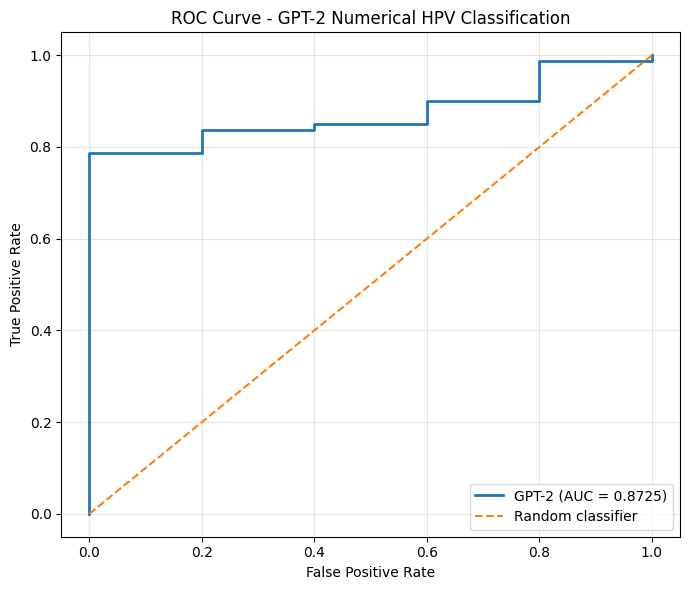

AUC: 0.8725


In [4]:
# ============================================================
# GPT-2 Numerical Tabular - HECKTOR - Seed 42 - No SMOTE
# ============================================================

!pip install -q gdown
import gdown
gdown.download(id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
               output="HPV2025.xlsx",quiet=False)

import os,random,numpy as np,pandas as pd
from torch.utils.data import TensorDataset,DataLoader
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,confusion_matrix,
    balanced_accuracy_score,roc_auc_score,f1_score
)
from transformers import GPT2Model

# ============================================================
# Reproducibility
# ============================================================

def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"]=str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
    torch.backends.cuda.matmul.allow_tf32=False
    torch.backends.cudnn.allow_tf32=False

SEED=42
seed_everything(SEED)

# ============================================================
# Device
# ============================================================

device=torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:",device)

# ============================================================
# Load and preprocess data
# ============================================================

df=pd.read_excel("HPV2025.xlsx")
df=df.dropna(subset=["HPV Status"])

tobacco_mode=df["Tobacco Consumption"].mode()[0]
df["Tobacco Consumption"]=df["Tobacco Consumption"].fillna(
    tobacco_mode
)

alcohol_mode=df["Alcohol Consumption"].mode()[0]
df["Alcohol Consumption"]=df["Alcohol Consumption"].fillna(
    alcohol_mode
)

df=df.drop(
    columns=["PatientID","CenterID","Task 1","Task 2","Task 3"]
)
df=df.dropna()

df["T-stage"]=df["T-stage"].replace(
    {"T0":0,"T1":1,"T2":2,"T3":3,"T4":4}
)
df["N-stage"]=df["N-stage"].replace(
    {"N0":0,"N1":1,"N2":2,"N3":3}
)
df["M-stage"]=df["M-stage"].replace(
    {"M0":0,"M1":1}
)

feature_columns=[
    "Age","Gender","Tobacco Consumption",
    "Alcohol Consumption","Performance Status",
    "Relapse","RFS","Treatment",
    "T-stage","N-stage","M-stage"
]

X=df[feature_columns].copy()
y=df["HPV Status"].copy()

print("Dataset shape:",df.shape)

# ============================================================
# Train-test split
# ============================================================

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=SEED,stratify=y
)

print("Train samples:")
print(y_train.value_counts())
print("\nTest samples:")
print(y_test.value_counts())

# ============================================================
# Standardisation
# ============================================================

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# ============================================================
# No SMOTE
# ============================================================

print("\nTraining samples without SMOTE:")
print(pd.Series(y_train).value_counts())

# ============================================================
# Convert to tensors
# ============================================================

X_train=torch.tensor(X_train,dtype=torch.float32)
y_train=torch.tensor(np.asarray(y_train),dtype=torch.long)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_test=torch.tensor(y_test.to_numpy(),dtype=torch.long)

# ============================================================
# DataLoaders
# ============================================================

BATCH_SIZE=256

train_dataset=TensorDataset(X_train,y_train)
test_dataset=TensorDataset(X_test,y_test)

train_generator=torch.Generator()
train_generator.manual_seed(SEED)

train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# GPT-2 model for numerical tabular features
# ============================================================

class HPVNetGPT2Numerical(nn.Module):
    def __init__(
        self,num_features=11,num_classes=2,
        model_name="openai-community/gpt2",
        dropout=0.1,freeze_gpt2=True
    ):
        super().__init__()
        self.num_features=num_features
        self.freeze_gpt2=freeze_gpt2
        self.gpt2=GPT2Model.from_pretrained(model_name)
        self.gpt2.config.use_cache=False
        hidden_size=self.gpt2.config.hidden_size

        self.feature_projection=nn.Sequential(
            nn.Linear(1,hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size)
        )

        self.feature_embedding=nn.Parameter(
            torch.empty(1,num_features,hidden_size)
        )

        self.classifier=nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size,128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128,num_classes)
        )

        nn.init.normal_(
            self.feature_embedding,
            mean=0.0,
            std=0.02
        )

        if freeze_gpt2:
            self.gpt2.requires_grad_(False)

    def train(self,mode=True):
        super().train(mode)
        if self.freeze_gpt2:
            self.gpt2.eval()
        return self

    def forward(self,x):
        x=x.unsqueeze(-1)
        x=self.feature_projection(x)
        x=x+self.feature_embedding

        outputs=self.gpt2(
            inputs_embeds=x,
            use_cache=False,
            return_dict=True
        )

        hidden_states=outputs.last_hidden_state
        pooled_output=hidden_states.mean(dim=1)
        logits=self.classifier(pooled_output)
        return logits

# ============================================================
# Model, loss and optimiser
# ============================================================

model=HPVNetGPT2Numerical(
    num_features=len(feature_columns),
    num_classes=2,
    freeze_gpt2=True
).to(device)

class_counts=np.bincount(y_train.numpy())
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weights=torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion=nn.CrossEntropyLoss(weight=class_weights)

optimizer=torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

# ============================================================
# Training
# ============================================================

EPOCHS=500
best_val_loss=float("inf")
best_epoch=0

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum=0.0
    train_sample_count=0

    for batch_x,batch_y in train_loader:
        batch_x=batch_x.to(device,non_blocking=True)
        batch_y=batch_y.to(device,non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs=model(batch_x)
        train_loss=criterion(outputs,batch_y)


        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            filter(
                lambda parameter: parameter.requires_grad,
                model.parameters()
            ),
            max_norm=1.0
        )

        optimizer.step()

        train_loss_sum+=(
            train_loss.item()*batch_x.size(0)
        )
        train_sample_count+=batch_x.size(0)

    average_train_loss=(
        train_loss_sum/train_sample_count
    )

    model.eval()
    test_loss_sum=0.0
    test_sample_count=0

    with torch.no_grad():
        for batch_x,batch_y in test_loader:
            batch_x=batch_x.to(device,non_blocking=True)
            batch_y=batch_y.to(device,non_blocking=True)

            test_outputs=model(batch_x)
            test_loss=criterion(test_outputs,batch_y)

            test_loss_sum+=(
                test_loss.item()*batch_x.size(0)
            )
            test_sample_count+=batch_x.size(0)

    average_test_loss=(
        test_loss_sum/test_sample_count
    )

    if average_test_loss<best_val_loss:
        best_val_loss=average_test_loss
        best_epoch=epoch+1

        torch.save(
            model.state_dict(),
            "best_model_gpt2_numerical.pth"
        )

    if (epoch+1)%10==0:
        print(
            f"Epoch {epoch+1:03d}, "
            f"Train={average_train_loss:.4f}, "
            f"Test={average_test_loss:.4f}, "
            f"Best Epoch={best_epoch}"
        )

print("\nBest Test Loss:",best_val_loss)
print("Best Epoch:",best_epoch)

# ============================================================
# Inference
# ============================================================

checkpoint=torch.load(
    "best_model_gpt2_numerical.pth",
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

all_probabilities=[]
all_predictions=[]
all_targets=[]

with torch.no_grad():
    for batch_x,batch_y in test_loader:
        batch_x=batch_x.to(device,non_blocking=True)

        outputs=model(batch_x)
        probabilities=torch.softmax(outputs,dim=1)
        predictions=torch.argmax(probabilities,dim=1)

        all_probabilities.append(probabilities.cpu())
        all_predictions.append(predictions.cpu())
        all_targets.append(batch_y.cpu())

probabilities=torch.cat(
    all_probabilities,dim=0
).numpy()

predicted=torch.cat(
    all_predictions,dim=0
).numpy()

y_true=torch.cat(
    all_targets,dim=0
).numpy()

# ============================================================
# Evaluation
# ============================================================

results=classification_report(
    y_true,
    predicted,
    digits=4,
    zero_division=0
)

print("\nClassification report:")
print(results)

bal_acc=balanced_accuracy_score(
    y_true,predicted
)

f1=f1_score(
    y_true,predicted,
    zero_division=0
)

auc=roc_auc_score(
    y_true,probabilities[:,1]
)

print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"F1-score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")

# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_score=probabilities[:,1]

fpr,tpr,thresholds=roc_curve(
    y_true,y_score
)

auc=roc_auc_score(
    y_true,y_score
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,tpr,
    linewidth=2,
    label=f'GPT-2 (AUC = {auc:.4f})'
)

plt.plot(
    [0,1],[0,1],
    linestyle='--',
    linewidth=1.5,
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(
    'ROC Curve - GPT-2 Numerical HPV Classification'
)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")